## Identifing the optimal point of a function

What is the optimal point of a function? It is the point where the function reaches its maximum or minimum value. In mathematical terms, it is the point where the derivative of the function equals zero.

### Landscape of a function

Rastrigin function is a non-convex function used as a performance test problem for optimization algorithms. It is defined as:
$$f(x) = A n + \sum_{i=1}^{n} [x_i^2 - A \cos(2 \pi x_i)]$$

Where:
- $x_i$ is the $i$-th component of the input vector $x$
- $A$ is a constant (usually set to 10)
- $n$ is the number of dimensions

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

def func(x):
	return 20 + sum(xi ** 2 - 10 * np.cos(2 * np.pi * xi) for xi in x)

### One dimensional case

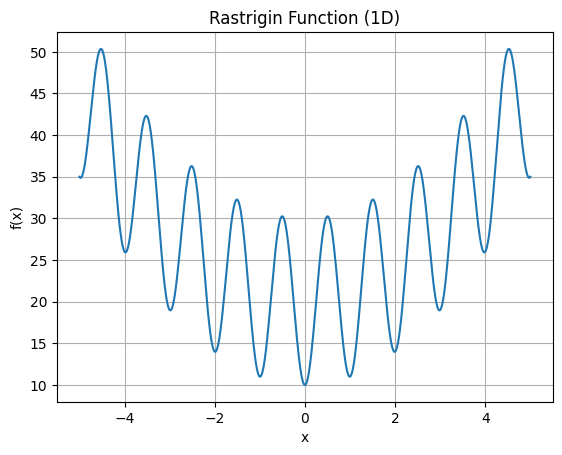

In [4]:
noDim = 1
x = np.linspace(-5, 5, 1000)
y = [func([xi]) for xi in x]
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Rastrigin Function (1D)')
plt.grid(True)
plt.show()

### Two dimensional case

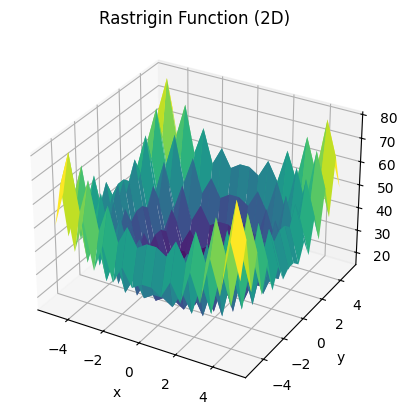

In [ ]:
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x, y)
Z = np.array([[func([xi, yi]) for xi in x] for yi in y])
plt.axes(projection='3d').plot_surface(X, Y, Z, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Rastrigin Function (2D)')
plt.show()

## GA running

GA stands for Genetic Algorithm, which is a search heuristic that mimics the process of natural selection. 

_this is so sad... i didn't have to write a single line of code because of this stupid lab :((_

In [48]:
from random import randint, uniform

class GA:
	def __init__(self, param = None, problparam = None):
		self.__param = param
		self.__problparam = problparam
		self.__population = []

	@property
	def population(self):
		return self.__population
	
	def initialisation(self):
		for _ in range(self.__param['pop_size']):
			individual = [uniform(self.__problparam['min'], self.__problparam['max']) for _ in range(self.__problparam['dim'])]
			self.__population.append(individual)

	def fitness(self, individual):
		return self.__problparam['func'](individual)
	
	def selection(self):
		fitness_values = [1 / (self.fitness(ind) + 1e-9) for ind in self.__population]
		total_fitness = sum(fitness_values)
		probabilities = [f / total_fitness for f in fitness_values]
		selected_index = np.random.choice(len(self.__population), p=probabilities)
		return self.__population[selected_index]
	
	def crossover(self, parent1, parent2):
		point = randint(0, self.__problparam['dim'])
		child1 = parent1[:point] + parent2[point:]
		child2 = parent2[:point] + parent1[point:]
		return child1, child2
	
	def mutation(self, individual):
		for i in range(len(individual)):
			if np.random.rand() < self.__param['mutation_rate']:
				individual[i] = uniform(self.__problparam['min'], self.__problparam['max'])

	def run(self):
		self.__population = []
		self.initialisation()
		for _ in range(self.__param['generations']):
			new_population = []
			for _ in range(self.__param['pop_size'] // 2):
				parent1 = self.selection()
				parent2 = self.selection()
				child1, child2 = self.crossover(parent1, parent2)
				self.mutation(child1)
				self.mutation(child2)
				new_population.extend([child1, child2])
			self.__population = new_population

	def best(self):
		return min(self.__population, key=lambda ind: self.fitness(ind))

In [45]:
parmas = {
	'pop_size' : 10,
	'mutation_rate' : 0.5,
  	'generations' : 100
}

problparams = {
	'min': -5,
	'max': 5,
	'func' : func,
	'dim': 1,
}

In [49]:
GArunner = GA(param=parmas, problparam=problparams)

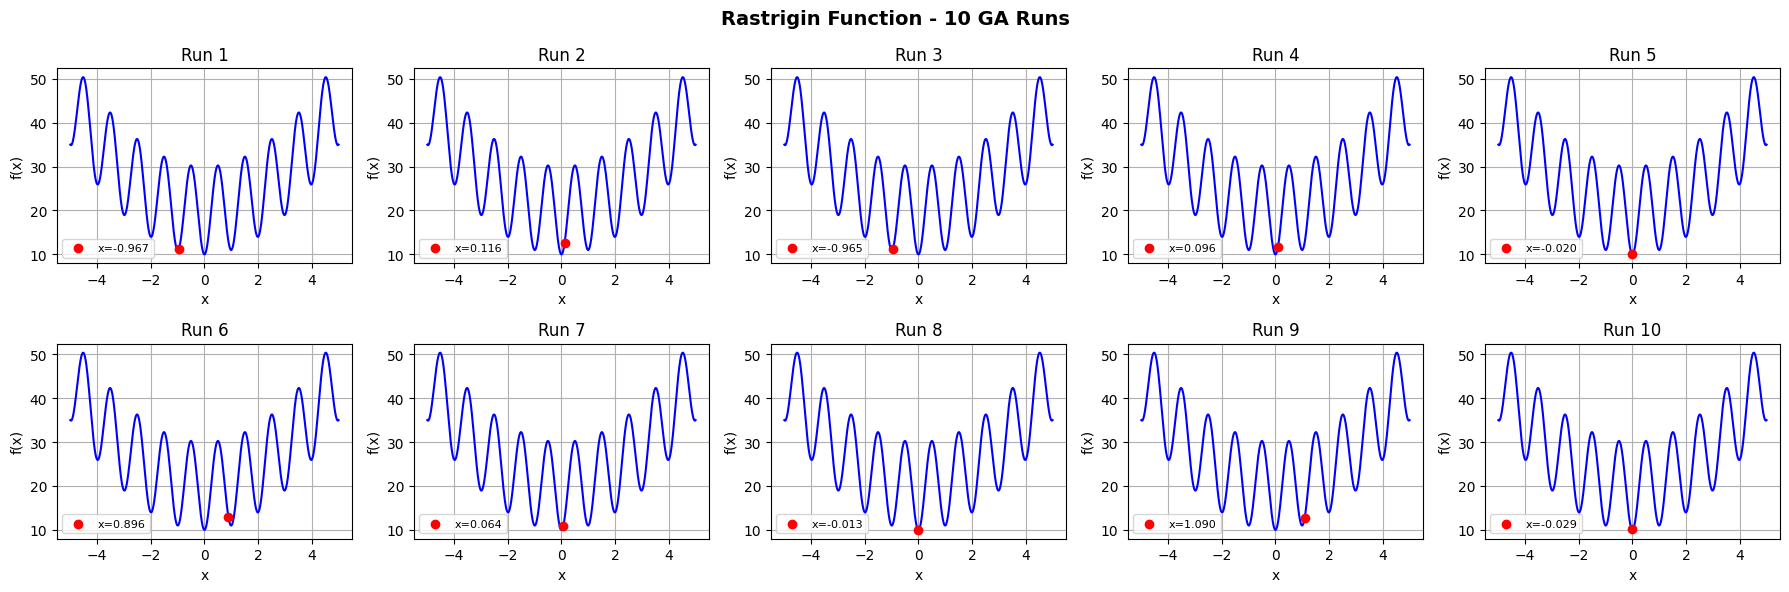

In [53]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

x = np.linspace(-5, 5, 1000)
y = [func([xi]) for xi in x]

for i, ax in enumerate(axes):
    GArunner.run()
    best = GArunner.best()

    ax.plot(x, y, 'b-')
    ax.scatter([best], [func(best)], color='red', zorder=5, label=f'x={best[0]:.3f}')
    ax.set_title(f'Run {i+1}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=8)

plt.suptitle('Rastrigin Function - 10 GA Runs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
problparams['dim'] = 2
GArunner = GA(param=parmas, problparam=problparams)

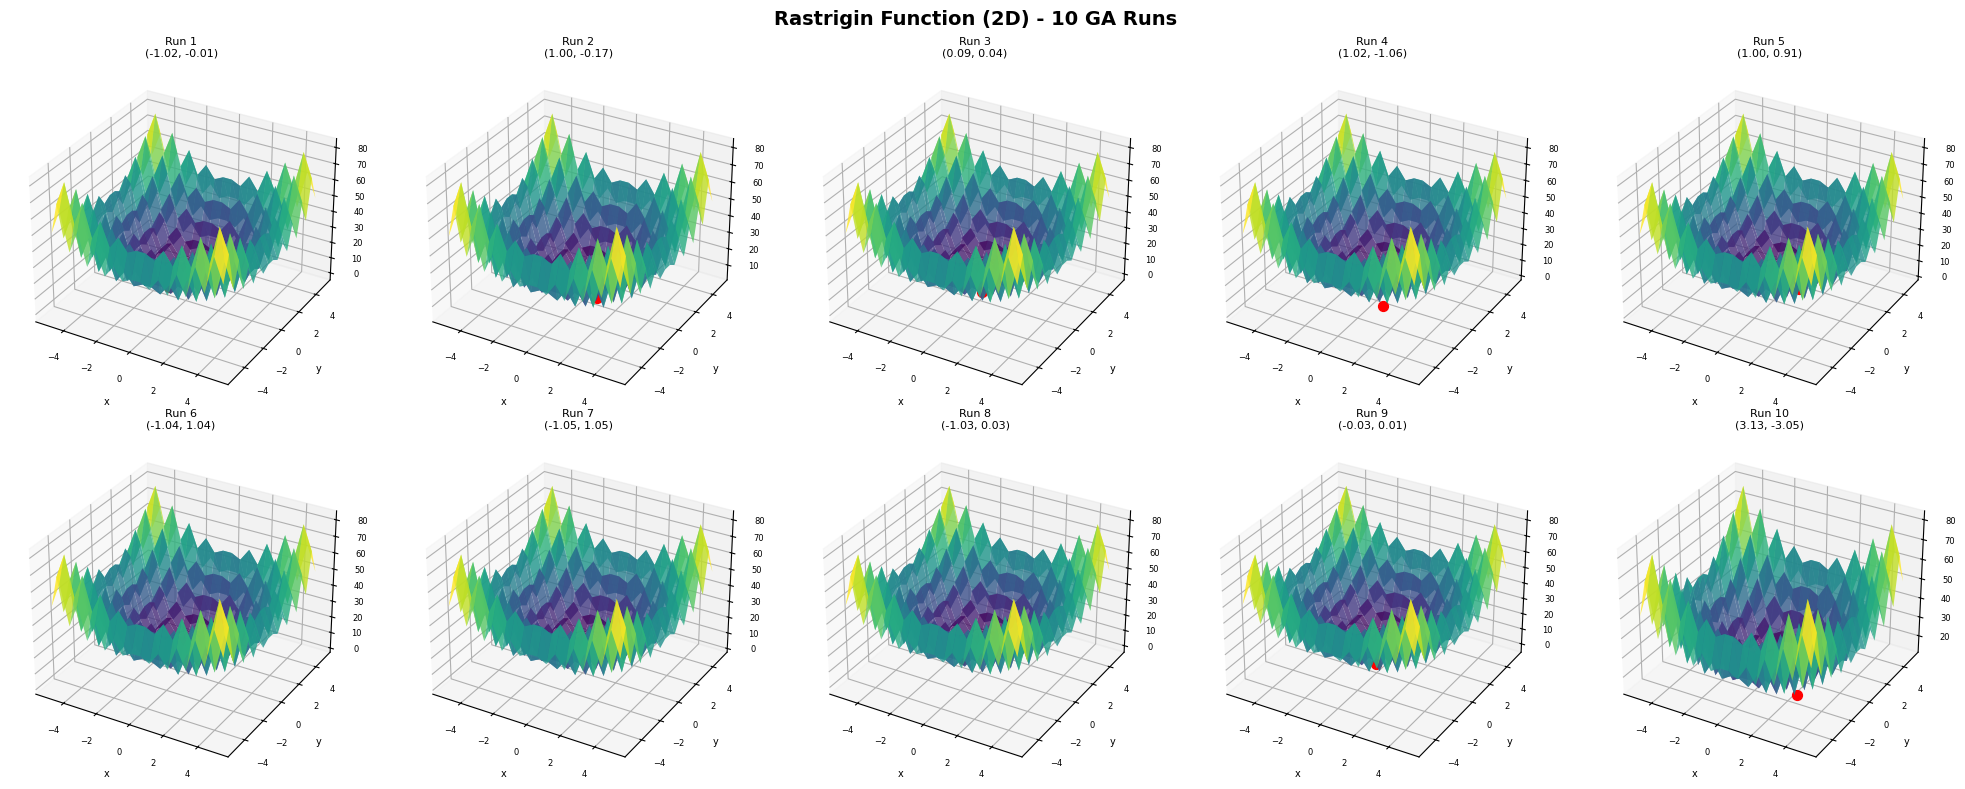

In [ ]:
fig = plt.figure(figsize=(20, 8))

x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x, y)
Z = np.array([[func([xi, yi]) for xi in x] for yi in y])

for i in range(10):
    GArunner.run()
    best = GArunner.best()
    point = np.array(best)

    ax = fig.add_subplot(2, 5, i + 1, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax.scatter([point[0]], [point[1]], [func(point)], color='red', s=50, zorder=5)
    ax.set_title(f'Run {i+1}\n({point[0]:.2f}, {point[1]:.2f})', fontsize=8)
    ax.set_xlabel('x', fontsize=7)
    ax.set_ylabel('y', fontsize=7)
    ax.tick_params(labelsize=6)

plt.suptitle('Rastrigin Function (2D) - 10 GA Runs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()